## Generate dust size distribution using adjustable logarithm

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def custom_log_space(min_exp, max_exp, num_points, density_param=1.0):
    """
    Generates an array with a non-uniform distribution in logarithmic space.

    Args:
        min_exp (float): The minimum exponent of 10 (e.g., -4 for 10^-4).
        max_exp (float): The maximum exponent of 10 (e.g., -1 for 10^-1).
        num_points (int): The number of points to generate.
        density_param (float): The density adjustment parameter.
            - density_param > 1: Points are denser at the start of the array (smaller values).
            - density_param = 1: Equivalent to np.linspace (standard log-uniform distribution).
            - density_param < 1: Points are denser at the end of the array (larger values).

    Returns:
        np.ndarray: The generated array of radius values.
    """
    # 1. Create a linear space from 0 to 1
    linear_space = np.linspace(0, 1, num_points)

    # 2. "Curve" this space using a power function
    curved_space = linear_space ** density_param

    # 3. Map the curved space to the actual exponent range [min_exp, max_exp]
    log_exponents = min_exp + (max_exp - min_exp) * curved_space

    # 4. Calculate the final radius values
    return 10 ** log_exponents

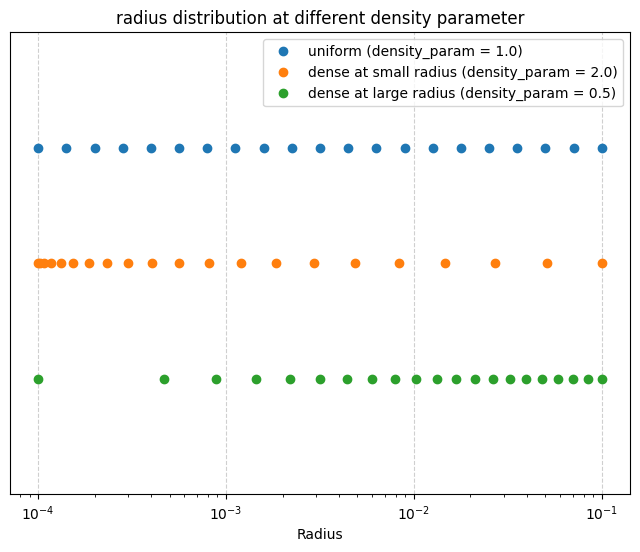

denser at small radius:
[0.0001     0.00010174 0.00010715 0.00011682 0.00013183 0.00015399
 0.00018621 0.00023308 0.000302   0.00040504 0.00056234 0.00080816
 0.00120226 0.0018514  0.00295121 0.00486968 0.00831764 0.01470618
 0.02691535 0.05099176 0.1       ]


In [8]:
# --- Example ---
min_exp = -4
max_exp = -1
num_points = 21

# Original method (equivalent to density_param=1.0)
original_radius = 10 ** np.linspace(min_exp, max_exp, num_points)

# dense at larger radius (density_param < 1)
dense_at_large_radius = custom_log_space(min_exp, max_exp, num_points, density_param=0.5)

# dense at smaller radius (density_param > 1)
dense_at_small_radius = custom_log_space(min_exp, max_exp, num_points, density_param=2.)

# visualization
plt.figure(figsize=(8, 6))
plt.plot(original_radius, np.ones(num_points) * 3, 'o', label='uniform (density_param = 1.0)')
plt.plot(dense_at_small_radius, np.ones(num_points) * 2, 'o', label='dense at small radius (density_param = 2.0)')
plt.plot(dense_at_large_radius, np.ones(num_points) * 1, 'o', label='dense at large radius (density_param = 0.5)')

plt.xscale('log')
plt.legend()
plt.title('radius distribution at different density parameter')
plt.xlabel('Radius')
plt.yticks([])
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.ylim(0, 4)
plt.show()

print("denser at small radius:")
print(dense_at_small_radius)

In [9]:
print(' '.join([f'{x:.5e}' for x in dense_at_small_radius]))

1.00000e-04 1.01742e-04 1.07152e-04 1.16815e-04 1.31826e-04 1.53993e-04 1.86209e-04 2.33077e-04 3.01995e-04 4.05042e-04 5.62341e-04 8.08165e-04 1.20226e-03 1.85140e-03 2.95121e-03 4.86968e-03 8.31764e-03 1.47062e-02 2.69153e-02 5.09918e-02 1.00000e-01


## calculate Q_pr (solar radiation pressure coefficient) for different particle radius

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import miepython as mie

# parameters
m = 0.8 - 0.01j
#m = 1.5

lambda0 = 500e-9  # wavelength in vacuum (m)

qext, qsca, qback, g = mie.efficiencies(m, 2*radius, lambda0)
qabs = qext - qsca
qpr = qabs + qsca * (1 - g)

In [17]:
qpr

array([0.7896391 , 0.79049632, 0.79110373, 0.79153521, 0.79184206,
       0.79206036, 0.79221568, 0.79232617, 0.79240475, 0.79246062,
       0.79250032, 0.79252853, 0.79254857, 0.7925628 , 0.7925729 ,
       0.79258006, 0.79258515, 0.79258875, 0.79259131, 0.79259312,
       0.79259441])

In [10]:
print(' '.join([f'{x}' for x in qpr]))

0.9657295642880123 0.9642472587126161 0.9631645314485191 0.9623757502470249 0.9618025260460947 0.9613869058033397 0.9610861978851055 0.9608690586254988 0.9607125482053487 0.960599926400405 0.960519010243386 0.9604609555448544 0.9604193567282803 0.9603895842638906 0.9603682987558388 0.9603530957095503 0.960342246619472 0.9603345107726866 0.9603289987996071 0.9603250739676048 0.9603222809260817


## Solar Radiation Pressure Compared to Gravitational Force

In [14]:
# solar radiation pressure compared to Didymos gravitational force
S = 1361         # W/m2
Qpr = 1
distance = 1e4   # m
c = 3e8          # m/s
rho_dust = 3000  # kg/m3
r_dust = 1e-1    # m
G = 6.6743e-11   # m3 / kg s2
M_didy = 5.5e11  # kg

# acceleration
a_rad = (3*S*Qpr) / (4*c*rho_dust*r_dust)
a_grav = G*M_didy/distance**2

# ratio
beta = (a_rad) / (a_grav)
print(f"beta = a_rad / a_grav = {beta}")

beta = a_rad / a_grav = 0.030896441756007555


In [20]:
# solar radiation pressure compared to Sun gravitational force
S = 1361         # W/m2
Qpr = 1
distance = 1.495978707e11   # m
c = 3e8          # m/s
rho_dust = 3000  # kg/m3
r_dust = 100e-6    # m
G = 6.6743e-11   # m3 / kg s2
M_didy = 1.9891e30  # kg

# acceleration
a_rad = (3*S*Qpr) / (4*c*rho_dust*r_dust)
a_grav = G*M_didy/distance**2

# ratio
beta = (a_rad) / (a_grav)
print(f"beta = a_rad / a_grav = {beta}")

beta = a_rad / a_grav = 0.0019119008320312182
